In [1]:
#Config 1: Minimal - Single hidden layer
config_1 = {
    'layers': [4],
    'activation': ['relu'],
    'dropout': [0.1]
}

# Config 2: Small but effective
config_2 = {
    'layers': [8, 4], 
    'activations': ['relu', 'relu'],
    'dropout': [0.2, 0.1]
}

# Config 3: Slightly wider
config_3 = {
    'layers': [16, 8], 
    'activations': ['tanh', 'relu'],
    'dropout': [0.3, 0.2]
}

In [2]:
# Config 4: Three layers, moderate size
config_4 = {
    'layers': [16, 8, 4], 
    'activations': ['relu', 'relu', 'relu'],
    'dropout': [0.2, 0.2, 0.1]
}

# Config 5: Uniform layer size
config_5 = {
    'layers': [12, 12, 12], 
    'activations': ['tanh', 'tanh', 'relu'],
    'dropout': [0.2, 0.2, 0.2]
}

# Config 6: Mixed activations
config_6 = {
    'layers': [32, 16, 8], 
    'activations': ['sigmoid', 'relu', 'tanh'],
    'dropout': [0.3, 0.2, 0.1]
}


In [3]:
# Config 7: Deep narrow network
config_7 = {
    'layers': [8, 8, 8, 8, 4], 
    'activations': ['relu', 'relu', 'relu', 'relu', 'relu'],
    'dropout': [0.1, 0.1, 0.1, 0.1, 0.1]
}

# Config 8: Wide then narrow
config_8 = {
    'layers': [64, 32, 16, 4], 
    'activations': ['relu', 'relu', 'tanh', 'relu'],
    'dropout': [0.4, 0.3, 0.2, 0.1]
}


## Implementation Framework

In [4]:
import tensorflow as tf
from sklearn.model_selection import cross_val_score
from sklearn.metrics import roc_auc_score, precision_recall_curve, auc
from sklearn.metrics import f1_score, precision_score, recall_score, roc_auc_score, roc_curve, precision_recall_curve, average_precision_score, accuracy_score


def create_nn_model(config, input_dim=2):
    """Create NN model based on configuration"""
    model = tf.keras.Sequential()
    
    # Input layer
    model.add(tf.keras.layers.Dense(
        config['layers'][0], 
        activation=config['activations'][0],
        input_shape=(input_dim,)
    ))
    
    # Add dropout if specified
    if 'dropout' in config and len(config['dropout']) > 0:
        model.add(tf.keras.layers.Dropout(config['dropout'][0]))
    
    # Hidden layers
    for i in range(1, len(config['layers'])):
        model.add(tf.keras.layers.Dense(
            config['layers'][i], 
            activation=config['activations'][i]
        ))
        
        if 'dropout' in config and i < len(config['dropout']):
            model.add(tf.keras.layers.Dropout(config['dropout'][i]))
    
    # Output layer (always sigmoid for binary classification)
    model.add(tf.keras.layers.Dense(1, activation='sigmoid'))
    
    return model

def evaluate_nn_config(config, X_train, y_train, X_test, y_test, config_name, model_container):
    """Evaluate a single NN configuration"""
    model = create_nn_model(config)
    model_container[config_name] = model
    # Compile model
    model.compile(
        optimizer='adam',
        loss='binary_crossentropy',
        metrics=['accuracy', 'precision', 'recall']
    )
    
    # Train with early stopping
    early_stopping = tf.keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=15,
        restore_best_weights=True
    )
    
    history = model.fit(
        X_train, y_train,
        epochs=100,
        batch_size=32,
        validation_split=0.2,
        callbacks=[early_stopping],
        verbose=0
    )
    
    # Evaluate
    y_pred_proba = model.predict(X_test).flatten()
    
    # Calculate metrics
    roc_auc = roc_auc_score(y_test, y_pred_proba)
    precision, recall, _ = precision_recall_curve(y_test, y_pred_proba)
    pr_auc = auc(recall, precision)
    
    # Get final metrics from training
    final_val_loss = min(history.history['val_loss'])
    epochs_trained = len(history.history['loss'])

    Y_actual = y_test
    Y_prob = y_pred_proba

     # --- Compute best F1 score by sweeping thresholds ---
    thresholds = np.linspace(0, 1, 101)  # thresholds from 0.0 to 1.0
    f1_scores = [f1_score(Y_actual, (Y_prob >= t).astype(int)) for t in thresholds]
    best_f1 = max(f1_scores)
    best_threshold = thresholds[np.argmax(f1_scores)]
    
    # Binary predictions using the best threshold
    Y_pred_best = (Y_prob >= best_threshold).astype(int)
    # --- ROC curve ---
    fpr, tpr, roc_thresholds = roc_curve(Y_actual, Y_prob)
    

    # --- Precision-Recall curve ---
    precision, recall, pr_thresholds = precision_recall_curve(Y_actual, Y_prob)
    avg_precision = average_precision_score(Y_actual, Y_prob)
    acc = accuracy_score(Y_actual, Y_pred_best)

    results = {
        'config_name': config_name,
        'roc_auc': roc_auc,
        'pr_auc': pr_auc,
        'val_loss': final_val_loss,
        'epochs': epochs_trained,
        'model': model,
        'history': history,
        "F1": best_f1,
        "Best_Threshold": best_threshold,
        "AUC": roc_auc_score(Y_actual, Y_prob),
        "Average_Precision": avg_precision,
        "Accuracy": acc

    }
    
    return results


In [5]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
#import xgboost as xgb
from sklearn.metrics import precision_recall_curve, auc
from sklearn.metrics import f1_score, precision_score, recall_score, accuracy_score
import lightgbm as lgb
import os


df = pd.read_csv("..\..\Meta Model Dataset\Training_For_Meta_Model.csv")
# Define target variable (presence of cardiovascular disease)
y = df["Cardiovascular Disease"]

# Select relevant features
features = ["Age", "Systolic Blood Pressure", "Diastolic Blood Pressure", "Cholesterol Level", "Glucose Level", "Smoking Status", "Alcohol Intake", "Physical Activity"]
X = df[features]

# Scale numerical features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.3, random_state=42, stratify=y)
lifestyle_columns_to_drop = ['Cholesterol Level', 'Diastolic Blood Pressure', 'Systolic Blood Pressure', 'Glucose Level', 'id']
health_columns_to_drop = ['Smoking Status', 'Physical Activity', 'Alcohol Intake', 'Age', 'Gender', 'BMI', 'id']

X = df.drop(['Cardiovascular Disease'], axis=1)
Y = df['Cardiovascular Disease']


X_train, X_test, Y_train, Y_test = train_test_split(
    X,
    Y,
    test_size=0.2, 
    random_state=42,
    stratify=Y 
)


health_dataset = X_train.drop(columns=health_columns_to_drop)
lifestyle_dataset = X_train.drop(columns=lifestyle_columns_to_drop)


# Load the trained models
#model_A = lgb.Booster(model_file="saved_models_tausif/lightgbm_model_A.txt")
# model_B = lgb.Booster(model_file="Models B/lightgbm_model.txt")
# model_A = lgb.Booster(model_file="Saved Models A/lightgbm_model.txt")
# Egula RETRAINED models 
model_A = lgb.Booster(model_file="lightgbm_model_A_withagb.txt")
model_B = lgb.Booster(model_file="lightgbm_model_B.txt")

predictions_A = model_A.predict(lifestyle_dataset)
predictions_B = model_B.predict(health_dataset)


print(predictions_A)
print(predictions_B)

<>:14: SyntaxWarning: invalid escape sequence '\.'
<>:14: SyntaxWarning: invalid escape sequence '\.'
C:\Users\adibs\AppData\Local\Temp\ipykernel_2648\3308054915.py:14: SyntaxWarning: invalid escape sequence '\.'
  df = pd.read_csv("..\..\Meta Model Dataset\Training_For_Meta_Model.csv")


[0.51450838 0.66875897 0.62748518 ... 0.35488267 0.33029411 0.32365621]
[0.22774369 0.9214363  0.8089465  ... 0.24437861 0.58089957 0.24437861]


In [6]:
import numpy as np
# Prepare meta-learner data (probabilities from Model A and B)
#a_g_BMI = X_train[['Age', 'Gender', 'BMI']].values
meta_X = np.column_stack([predictions_A, predictions_B])

meta_y = Y_train.values

# Split for meta-learner training
X_train_meta, X_test_meta, y_train_meta, y_test_meta = train_test_split(
    meta_X, meta_y, test_size=0.2, random_state=42, stratify=meta_y
)

# Test all configurations
configurations = {
    'Simple_4': {'layers': [4], 'activations': ['relu'], 'dropout': [0.1]},
    'Small_8-4': {'layers': [8, 4], 'activations': ['relu', 'relu'], 'dropout': [0.2, 0.1]},
    'Medium_16-8': {'layers': [16, 8], 'activations': ['tanh', 'relu'], 'dropout': [0.3, 0.2]},
    'Triple_16-8-4': {'layers': [16, 8, 4], 'activations': ['relu', 'relu', 'relu'], 'dropout': [0.2, 0.2, 0.1]},
    'Uniform_12x3': {'layers': [12, 12, 12], 'activations': ['tanh', 'tanh', 'relu'], 'dropout': [0.2, 0.2, 0.2]},
    'Mixed_32-16-8': {'layers': [32, 16, 8], 'activations': ['sigmoid', 'relu', 'tanh'], 'dropout': [0.3, 0.2, 0.1]},
    'Deep_8x5': {'layers': [8, 8, 8, 8, 4], 'activations': ['relu']*5, 'dropout': [0.1]*5},
    'Wide_64-32-16-4': {'layers': [64, 32, 16, 4], 'activations': ['relu', 'relu', 'tanh', 'relu'], 'dropout': [0.4, 0.3, 0.2, 0.1]}
}

results = {}
model_container = {}
for config_name, config in configurations.items():
    print(f"Testing {config_name}...")
    result = evaluate_nn_config(
        config, X_train_meta, y_train_meta, X_test_meta, y_test_meta, config_name, model_container
    )
    results[config_name] = result


Testing Simple_4...


C:\Users\adibs\AppData\Roaming\Python\Python312\site-packages\keras\src\layers\core\dense.py:92: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 879us/step
Testing Small_8-4...


C:\Users\adibs\AppData\Roaming\Python\Python312\site-packages\keras\src\layers\core\dense.py:92: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 911us/step
Testing Medium_16-8...


...

69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  
Testing Deep_8x5...


C:\Users\adibs\AppData\Roaming\Python\Python312\site-packages\keras\src\layers\core\dense.py:92: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  
Testing Wide_64-32-16-4...


C:\Users\adibs\AppData\Roaming\Python\Python312\site-packages\keras\src\layers\core\dense.py:92: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  


In [7]:
import pandas as pd

# Create results comparison
comparison_data = []
for name, result in results.items():
    comparison_data.append({
        'Configuration': name,
        'ROC-AUC': result['roc_auc'],
        'PR-AUC': result['pr_auc'],
        'Val_Loss': result['val_loss'],
        'Epochs': result['epochs'],
        'F1': result['F1'],
        'Best_Threshold': result['Best_Threshold'],
        'AUC': result['AUC'],
        'Average_Precision': result['Average_Precision'],
        'Accuracy': result['Accuracy']
    })

results_df = pd.DataFrame(comparison_data)
results_df = results_df.sort_values('PR-AUC', ascending=False)
print(results_df)


     Configuration   ROC-AUC    PR-AUC  Val_Loss  Epochs        F1  \
7  Wide_64-32-16-4  0.783688  0.768769  0.554375      48  0.726964   
1        Small_8-4  0.782739  0.768576  0.560417      81  0.725973   
3    Triple_16-8-4  0.783443  0.768387  0.556849      66  0.727352   
6         Deep_8x5  0.782631  0.767963  0.563082      59  0.727043   
2      Medium_16-8  0.782372  0.767184  0.556339      53  0.725966   
4     Uniform_12x3  0.782620  0.766690  0.555839      25  0.726316   
5    Mixed_32-16-8  0.782353  0.766547  0.557400      79  0.725078   
0         Simple_4  0.782191  0.765404  0.557884      61  0.726311   

   Best_Threshold       AUC  Average_Precision  Accuracy  
7            0.35  0.783688           0.769249  0.705721  
1            0.36  0.782739           0.768980  0.684211  
3            0.41  0.783443           0.768873  0.714874  
6            0.34  0.782631           0.768447  0.703432  
2            0.41  0.782372           0.767667  0.720824  
4            0.

In [8]:
# Optional: Re-evaluate a specific configuration (Triple_16-8-4)
# This cell is optional and can be skipped - all models are already trained above

# Uncomment below to retrain Triple_16-8-4
# best_config_name = "Triple_16-8-4"
# best_config = configurations[best_config_name]
# 
# print(f"Re-testing {best_config_name}...")
# result = evaluate_nn_config(
#     best_config, X_train_meta, y_train_meta, X_test_meta, y_test_meta, best_config_name, model_container
# )
# results[best_config_name] = result
# 
# comparison_data = []
# for name, result in results.items():
#     comparison_data.append({
#         'Configuration': name,
#         'ROC-AUC': result['roc_auc'],
#         'PR-AUC': result['pr_auc'],
#         'Val_Loss': result['val_loss'],
#         'Epochs': result['epochs'],
#         'F1': result['F1'],
#         'Best_Threshold': result['Best_Threshold'],
#         'AUC': result['AUC'],
#         'Average_Precision': result['Average_Precision'],
#         'Accuracy': result['Accuracy']
#     })
# 
# results_df = pd.DataFrame(comparison_data)
# results_df = results_df.sort_values('PR-AUC', ascending=False)
# print(results_df)

print("Skipping re-evaluation. All models already trained in previous cell.")



Skipping re-evaluation. All models already trained in previous cell.


In [9]:
# Save all models for future use
print("Saving all trained models...")
for model_name, model in model_container.items():
    model.save(f'{model_name}_meta_model.h5')
    print(f"  - Saved: {model_name}_meta_model.h5")
print("\nAll models saved successfully!")

Saving all trained models...
  - Saved: Simple_4_meta_model.h5


  - Saved: Small_8-4_meta_model.h5
  - Saved: Medium_16-8_meta_model.h5
  - Saved: Triple_16-8-4_meta_model.h5
  - Saved: Uniform_12x3_meta_model.h5
  - Saved: Mixed_32-16-8_meta_model.h5
  - Saved: Deep_8x5_meta_model.h5
  - Saved: Wide_64-32-16-4_meta_model.h5

All models saved successfully!


## Comprehensive Meta-Model Evaluation

In [10]:
# Evaluate Simple_4 model
model_name = 'Simple_4'
print(f"Evaluating model: {model_name}")
print("\n" + "="*80)

# Get predictions from Simple_4 model
best_model = model_container[model_name]
y_pred_proba = best_model.predict(X_test_meta).flatten()

# Use best threshold from training results
best_threshold = results[model_name]['Best_Threshold']
y_pred = (y_pred_proba >= best_threshold).astype(int)

print(f"Best Threshold: {best_threshold:.4f}")
print(f"Predictions shape: {y_pred.shape}")
print(f"Test labels shape: {y_test_meta.shape}")

Evaluating model: Simple_4

69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 592us/step
Best Threshold: 0.3900
Predictions shape: (2185,)
Test labels shape: (2185,)


Confusion Matrix:
[[740 361]
 [260 824]]


Classification Report:
              precision    recall  f1-score   support

      No CVD       0.74      0.67      0.70      1101
         CVD       0.70      0.76      0.73      1084

    accuracy                           0.72      2185
   macro avg       0.72      0.72      0.72      2185
weighted avg       0.72      0.72      0.72      2185



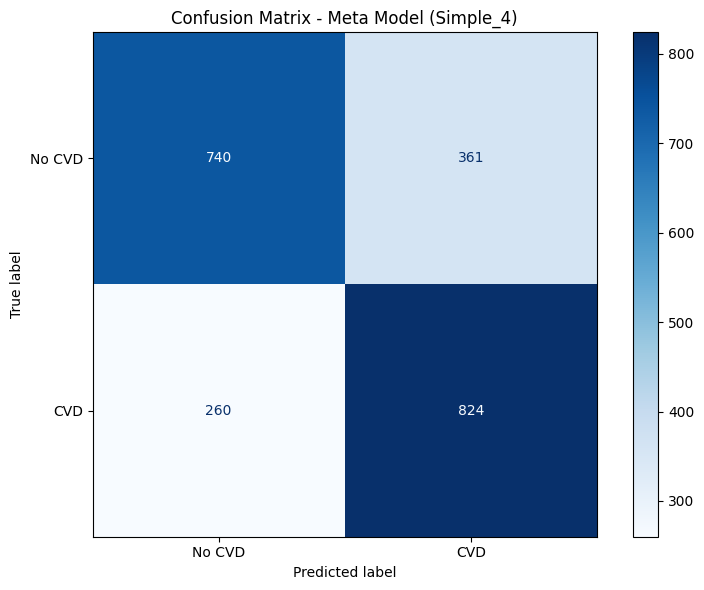


Confusion matrix saved to confusion_matrix.csv


In [11]:
# Confusion Matrix and Classification Report
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay
import seaborn as sns

# Confusion Matrix
cm = confusion_matrix(y_test_meta, y_pred)
print("Confusion Matrix:")
print(cm)
print("\n")

# Classification Report
print("Classification Report:")
print(classification_report(y_test_meta, y_pred, target_names=['No CVD', 'CVD']))

# Visualize Confusion Matrix
fig, ax = plt.subplots(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No CVD', 'CVD'])
disp.plot(ax=ax, cmap='Blues', values_format='d')
plt.title('Confusion Matrix - Meta Model (Simple_4)')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

# Save confusion matrix to CSV
cm_df = pd.DataFrame(cm, 
                     index=['Actual No CVD', 'Actual CVD'],
                     columns=['Predicted No CVD', 'Predicted CVD'])
cm_df.to_csv('confusion_matrix.csv')
print("\nConfusion matrix saved to confusion_matrix.csv")

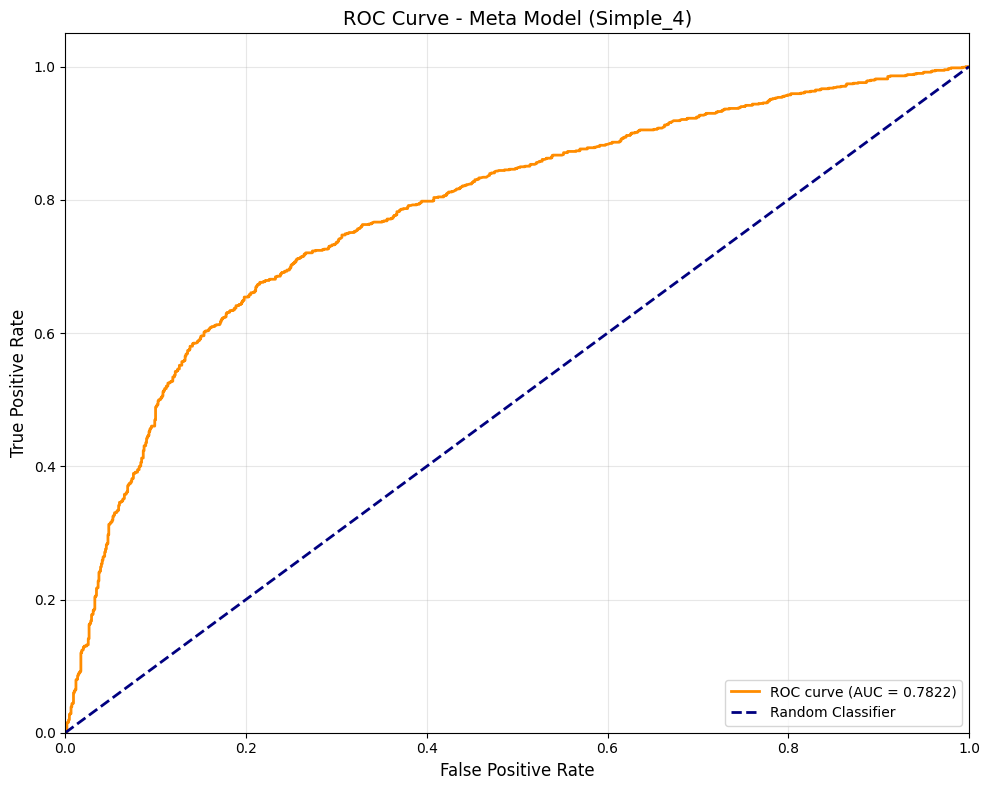

ROC-AUC Score: 0.7822
ROC curve points saved to roc_curve_points.csv


In [12]:
# ROC Curve Analysis
from sklearn.metrics import roc_curve, roc_auc_score

fpr, tpr, roc_thresholds = roc_curve(y_test_meta, y_pred_proba)
roc_auc = roc_auc_score(y_test_meta, y_pred_proba)

# Plot ROC Curve
plt.figure(figsize=(10, 8))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Classifier')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curve - Meta Model (Simple_4)', fontsize=14)
plt.legend(loc="lower right", fontsize=10)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('roc_curve.png', dpi=300, bbox_inches='tight')
plt.show()

# Save ROC curve points to CSV
roc_df = pd.DataFrame({
    'False_Positive_Rate': fpr,
    'True_Positive_Rate': tpr,
    'Threshold': roc_thresholds
})
roc_df.to_csv('roc_curve_points.csv', index=False)
print(f"ROC-AUC Score: {roc_auc:.4f}")
print("ROC curve points saved to roc_curve_points.csv")

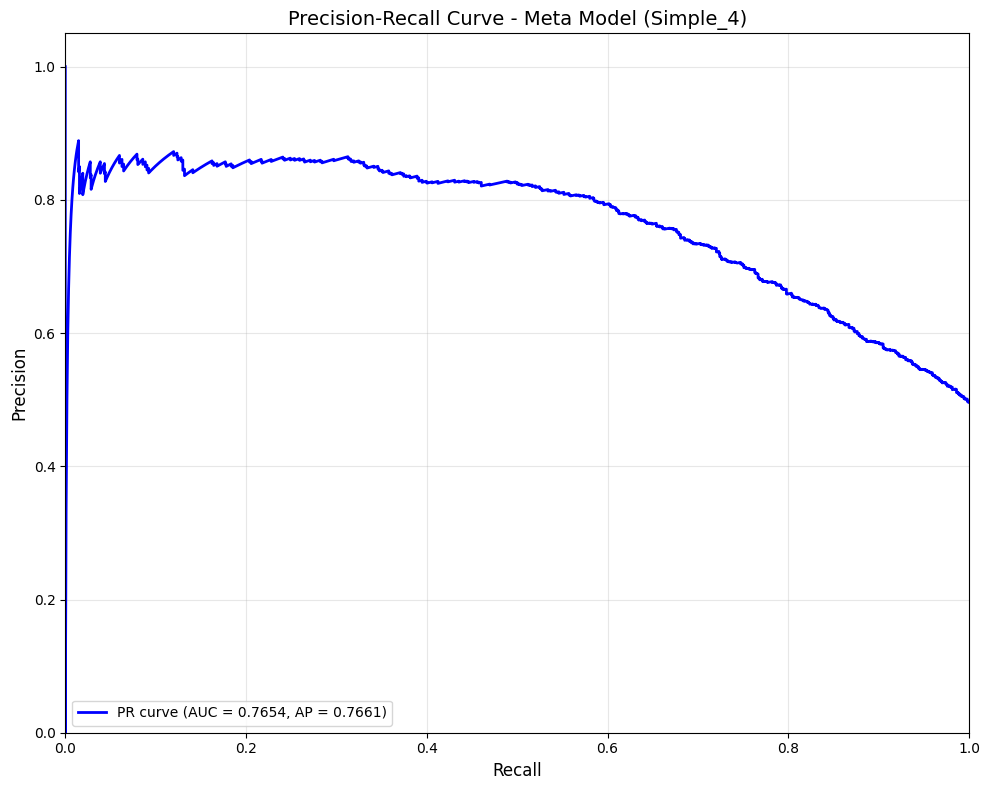

PR-AUC Score: 0.7654
Average Precision: 0.7661
Precision-Recall curve points saved to precision_recall_curve_points.csv


In [13]:
# Precision-Recall Curve Analysis
from sklearn.metrics import precision_recall_curve, average_precision_score

precision, recall, pr_thresholds = precision_recall_curve(y_test_meta, y_pred_proba)
pr_auc = auc(recall, precision)
avg_precision = average_precision_score(y_test_meta, y_pred_proba)

# Plot Precision-Recall Curve
plt.figure(figsize=(10, 8))
plt.plot(recall, precision, color='blue', lw=2, label=f'PR curve (AUC = {pr_auc:.4f}, AP = {avg_precision:.4f})')
plt.xlabel('Recall', fontsize=12)
plt.ylabel('Precision', fontsize=12)
plt.title('Precision-Recall Curve - Meta Model (Simple_4)', fontsize=14)
plt.legend(loc="lower left", fontsize=10)
plt.grid(alpha=0.3)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.tight_layout()
plt.savefig('precision_recall_curve.png', dpi=300, bbox_inches='tight')
plt.show()

# Save PR curve points to CSV
pr_df = pd.DataFrame({
    'Recall': recall,
    'Precision': precision,
    'Threshold': np.append(pr_thresholds, np.nan)  # PR thresholds are 1 less than precision/recall
})
pr_df.to_csv('precision_recall_curve_points.csv', index=False)
print(f"PR-AUC Score: {pr_auc:.4f}")
print(f"Average Precision: {avg_precision:.4f}")
print("Precision-Recall curve points saved to precision_recall_curve_points.csv")

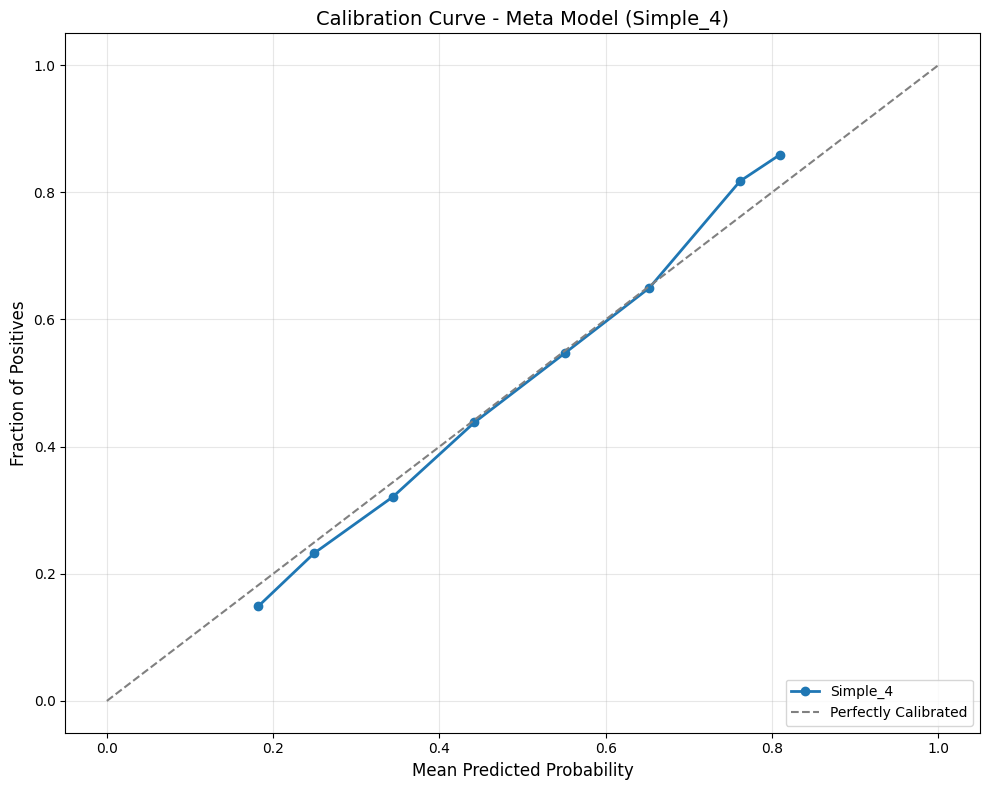

Calibration curve saved to calibration_curve_points.csv


In [14]:
# Calibration Curve
from sklearn.calibration import calibration_curve

prob_true, prob_pred = calibration_curve(y_test_meta, y_pred_proba, n_bins=10, strategy='uniform')

plt.figure(figsize=(10, 8))
plt.plot(prob_pred, prob_true, marker='o', linewidth=2, label='Simple_4')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Perfectly Calibrated')
plt.xlabel('Mean Predicted Probability', fontsize=12)
plt.ylabel('Fraction of Positives', fontsize=12)
plt.title('Calibration Curve - Meta Model (Simple_4)', fontsize=14)
plt.legend(loc='lower right', fontsize=10)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('calibration_curve.png', dpi=300, bbox_inches='tight')
plt.show()

# Save calibration curve to CSV
calib_df = pd.DataFrame({
    'Mean_Predicted_Probability': prob_pred,
    'Fraction_of_Positives': prob_true
})
calib_df.to_csv('calibration_curve_points.csv', index=False)
print("Calibration curve saved to calibration_curve_points.csv")

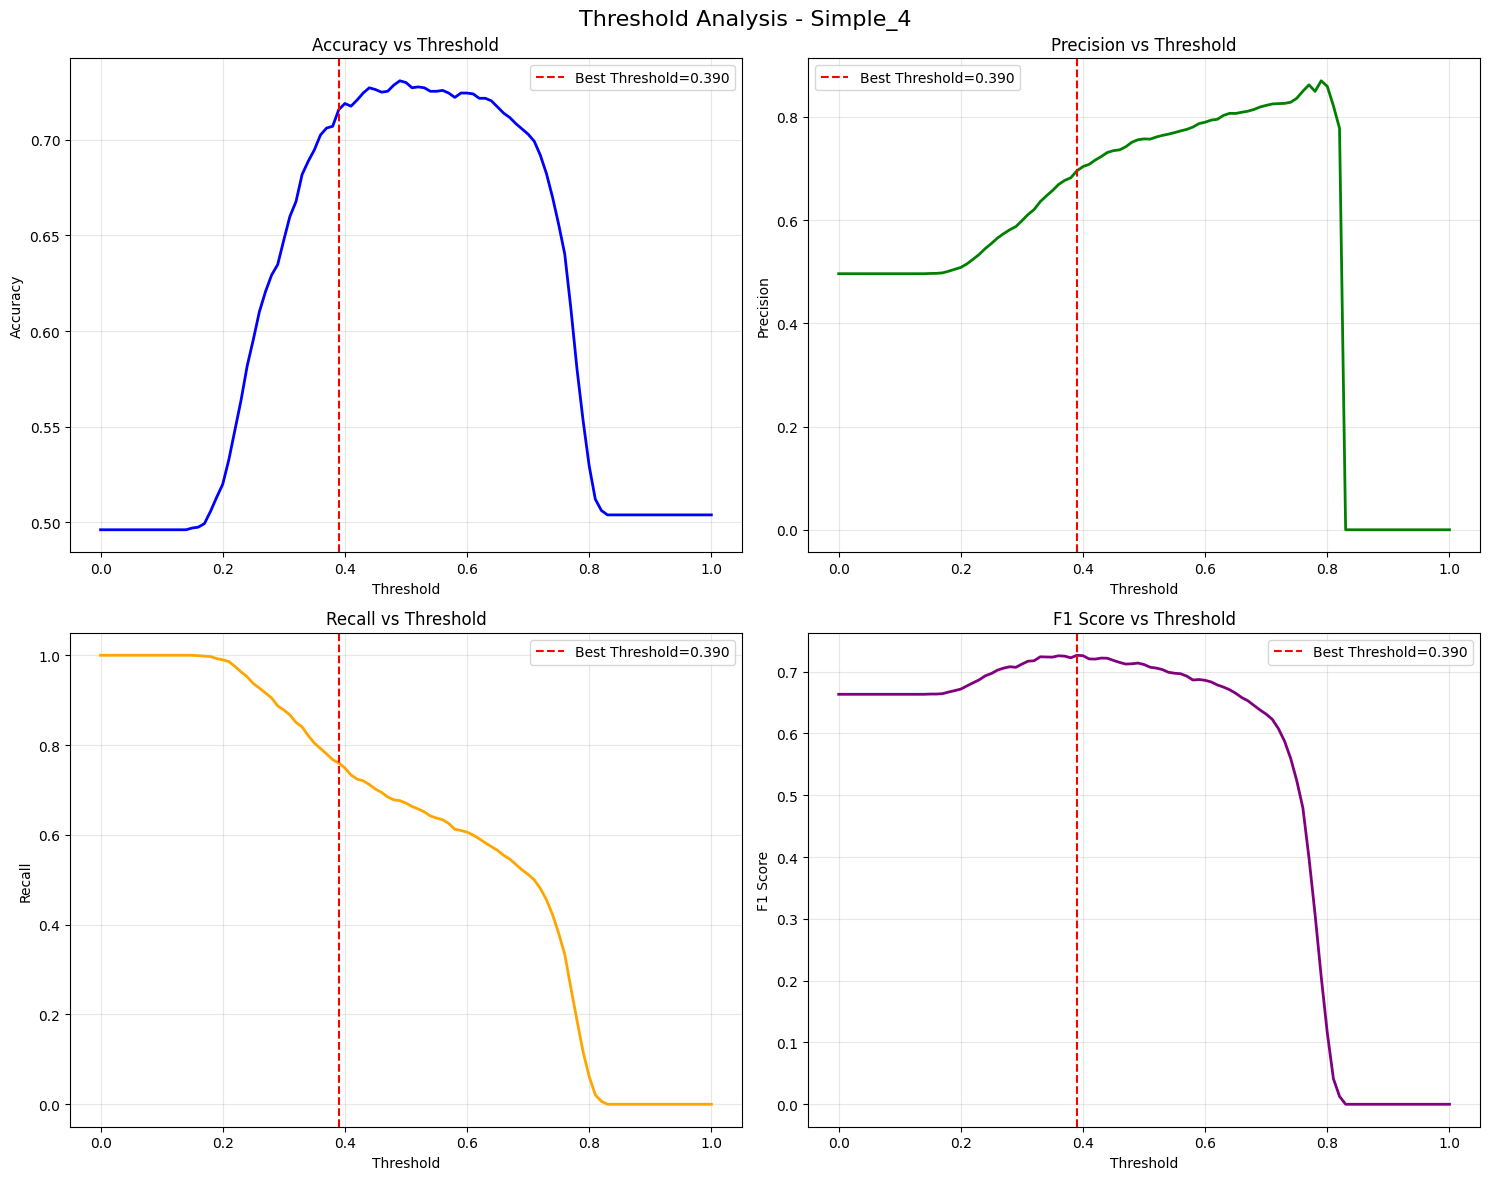

Threshold analysis saved to threshold_analysis.csv


In [15]:
# Threshold Analysis - Evaluate metrics across different thresholds
thresholds_range = np.linspace(0, 1, 101)
metrics_by_threshold = []

for thresh in thresholds_range:
    y_pred_thresh = (y_pred_proba >= thresh).astype(int)
    
    metrics_by_threshold.append({
        'Threshold': thresh,
        'Accuracy': accuracy_score(y_test_meta, y_pred_thresh),
        'Precision': precision_score(y_test_meta, y_pred_thresh, zero_division=0),
        'Recall': recall_score(y_test_meta, y_pred_thresh, zero_division=0),
        'F1_Score': f1_score(y_test_meta, y_pred_thresh, zero_division=0)
    })

threshold_df = pd.DataFrame(metrics_by_threshold)

# Plot metrics vs threshold
fig, axes = plt.subplots(2, 2, figsize=(15, 12))
fig.suptitle('Threshold Analysis - Simple_4', fontsize=16)

axes[0, 0].plot(threshold_df['Threshold'], threshold_df['Accuracy'], 'b-', linewidth=2)
axes[0, 0].axvline(x=best_threshold, color='r', linestyle='--', label=f'Best Threshold={best_threshold:.3f}')
axes[0, 0].set_xlabel('Threshold')
axes[0, 0].set_ylabel('Accuracy')
axes[0, 0].set_title('Accuracy vs Threshold')
axes[0, 0].legend()
axes[0, 0].grid(alpha=0.3)

axes[0, 1].plot(threshold_df['Threshold'], threshold_df['Precision'], 'g-', linewidth=2)
axes[0, 1].axvline(x=best_threshold, color='r', linestyle='--', label=f'Best Threshold={best_threshold:.3f}')
axes[0, 1].set_xlabel('Threshold')
axes[0, 1].set_ylabel('Precision')
axes[0, 1].set_title('Precision vs Threshold')
axes[0, 1].legend()
axes[0, 1].grid(alpha=0.3)

axes[1, 0].plot(threshold_df['Threshold'], threshold_df['Recall'], 'orange', linewidth=2)
axes[1, 0].axvline(x=best_threshold, color='r', linestyle='--', label=f'Best Threshold={best_threshold:.3f}')
axes[1, 0].set_xlabel('Threshold')
axes[1, 0].set_ylabel('Recall')
axes[1, 0].set_title('Recall vs Threshold')
axes[1, 0].legend()
axes[1, 0].grid(alpha=0.3)

axes[1, 1].plot(threshold_df['Threshold'], threshold_df['F1_Score'], 'purple', linewidth=2)
axes[1, 1].axvline(x=best_threshold, color='r', linestyle='--', label=f'Best Threshold={best_threshold:.3f}')
axes[1, 1].set_xlabel('Threshold')
axes[1, 1].set_ylabel('F1 Score')
axes[1, 1].set_title('F1 Score vs Threshold')
axes[1, 1].legend()
axes[1, 1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('threshold_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

# Save threshold analysis to CSV
threshold_df.to_csv('threshold_analysis.csv', index=False)
print("Threshold analysis saved to threshold_analysis.csv")

In [16]:
# Comprehensive Metrics Summary
from sklearn.metrics import matthews_corrcoef, cohen_kappa_score, balanced_accuracy_score

# Calculate all metrics
tn, fp, fn, tp = cm.ravel()

metrics_summary = {
    'Model_Name': ['Simple_4'],
    'Accuracy': [accuracy_score(y_test_meta, y_pred)],
    'Balanced_Accuracy': [balanced_accuracy_score(y_test_meta, y_pred)],
    'Precision': [precision_score(y_test_meta, y_pred)],
    'Recall': [recall_score(y_test_meta, y_pred)],
    'F1_Score': [f1_score(y_test_meta, y_pred)],
    'ROC_AUC': [roc_auc],
    'PR_AUC': [pr_auc],
    'Average_Precision': [avg_precision],
    'Matthews_Corr_Coef': [matthews_corrcoef(y_test_meta, y_pred)],
    'Cohen_Kappa': [cohen_kappa_score(y_test_meta, y_pred)],
    'Specificity': [tn / (tn + fp)],
    'NPV': [tn / (tn + fn)],  # Negative Predictive Value
    'FPR': [fp / (fp + tn)],  # False Positive Rate
    'FNR': [fn / (fn + tp)],  # False Negative Rate
    'True_Positives': [tp],
    'True_Negatives': [tn],
    'False_Positives': [fp],
    'False_Negatives': [fn],
    'Best_Threshold': [best_threshold],
    'Total_Samples': [len(y_test_meta)],
    'Positive_Samples': [sum(y_test_meta)],
    'Negative_Samples': [len(y_test_meta) - sum(y_test_meta)]
}

metrics_df = pd.DataFrame(metrics_summary)

# Display all metrics
print("="*80)
print("COMPREHENSIVE METRICS SUMMARY - Simple_4")
print("="*80)
for col in metrics_df.columns:
    if col != 'Model_Name':
        print(f"{col}: {metrics_df[col].values[0]:.6f}")
print("="*80)

# Save comprehensive metrics to CSV
metrics_df.to_csv('comprehensive_metrics_summary.csv', index=False)
print("\nComprehensive metrics saved to comprehensive_metrics_summary.csv")

COMPREHENSIVE METRICS SUMMARY - Simple_4
Accuracy: 0.715789
Balanced_Accuracy: 0.716132
Precision: 0.695359
Recall: 0.760148
F1_Score: 0.726311
ROC_AUC: 0.782191
PR_AUC: 0.765404
Average_Precision: 0.766078
Matthews_Corr_Coef: 0.433808
Cohen_Kappa: 0.431953
Specificity: 0.672116
NPV: 0.740000
FPR: 0.327884
FNR: 0.239852
True_Positives: 824.000000
True_Negatives: 740.000000
False_Positives: 361.000000
False_Negatives: 260.000000
Best_Threshold: 0.390000
Total_Samples: 2185.000000
Positive_Samples: 1084.000000
Negative_Samples: 1101.000000

Comprehensive metrics saved to comprehensive_metrics_summary.csv


In [17]:
# Model Predictions Analysis - Save predictions with actual values
predictions_analysis = pd.DataFrame({
    'Actual': y_test_meta,
    'Predicted_Probability': y_pred_proba,
    'Predicted_Class': y_pred,
    'Correct_Prediction': (y_test_meta == y_pred).astype(int),
    'Model_A_Prediction': X_test_meta[:, 0],
    'Model_B_Prediction': X_test_meta[:, 1]
})

# Add prediction confidence
predictions_analysis['Prediction_Confidence'] = np.maximum(y_pred_proba, 1 - y_pred_proba)

# Classify prediction types
predictions_analysis['Prediction_Type'] = 'Unknown'
predictions_analysis.loc[(predictions_analysis['Actual'] == 1) & (predictions_analysis['Predicted_Class'] == 1), 'Prediction_Type'] = 'True Positive'
predictions_analysis.loc[(predictions_analysis['Actual'] == 0) & (predictions_analysis['Predicted_Class'] == 0), 'Prediction_Type'] = 'True Negative'
predictions_analysis.loc[(predictions_analysis['Actual'] == 0) & (predictions_analysis['Predicted_Class'] == 1), 'Prediction_Type'] = 'False Positive'
predictions_analysis.loc[(predictions_analysis['Actual'] == 1) & (predictions_analysis['Predicted_Class'] == 0), 'Prediction_Type'] = 'False Negative'

# Save predictions to CSV
predictions_analysis.to_csv('model_predictions_analysis.csv', index=False)
print("Predictions analysis saved to model_predictions_analysis.csv")
print(f"\nPrediction Types Distribution:")
print(predictions_analysis['Prediction_Type'].value_counts())
print(f"\nAverage Prediction Confidence: {predictions_analysis['Prediction_Confidence'].mean():.4f}")

Predictions analysis saved to model_predictions_analysis.csv

Prediction Types Distribution:
Prediction_Type
True Positive     824
True Negative     740
False Positive    361
False Negative    260
Name: count, dtype: int64

Average Prediction Confidence: 0.7032


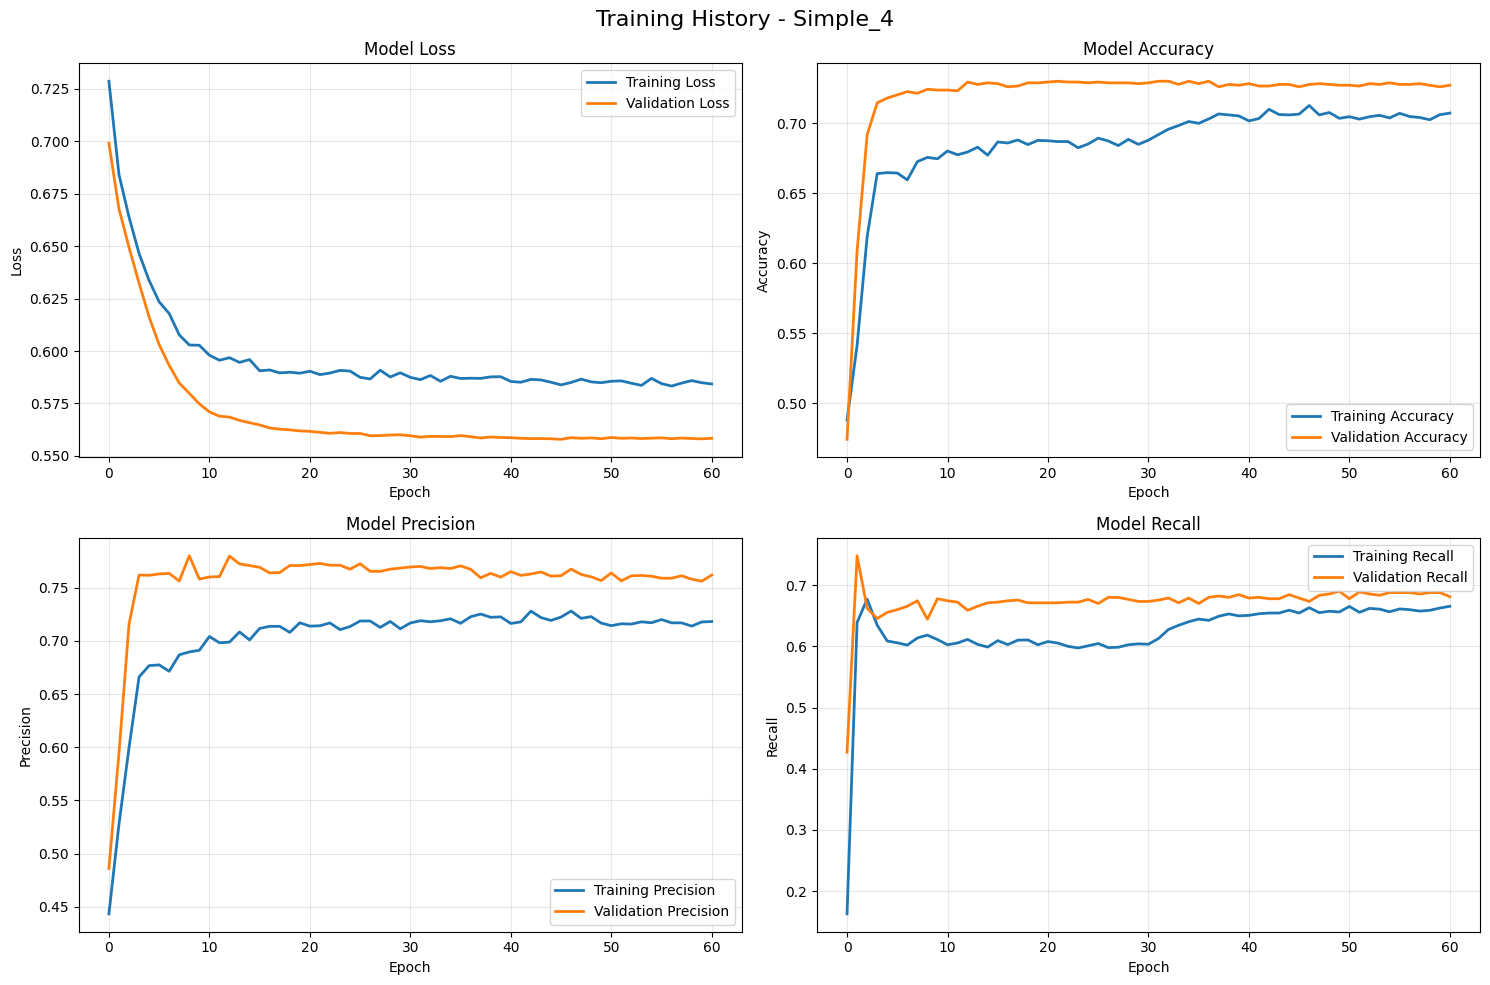

Training history saved to training_history.csv


In [18]:
# Training History Analysis
history = results['Simple_4']['history']

# Plot training history
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle('Training History - Simple_4', fontsize=16)

# Loss
axes[0, 0].plot(history.history['loss'], label='Training Loss', linewidth=2)
axes[0, 0].plot(history.history['val_loss'], label='Validation Loss', linewidth=2)
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('Loss')
axes[0, 0].set_title('Model Loss')
axes[0, 0].legend()
axes[0, 0].grid(alpha=0.3)

# Accuracy
axes[0, 1].plot(history.history['accuracy'], label='Training Accuracy', linewidth=2)
axes[0, 1].plot(history.history['val_accuracy'], label='Validation Accuracy', linewidth=2)
axes[0, 1].set_xlabel('Epoch')
axes[0, 1].set_ylabel('Accuracy')
axes[0, 1].set_title('Model Accuracy')
axes[0, 1].legend()
axes[0, 1].grid(alpha=0.3)

# Precision
axes[1, 0].plot(history.history['precision'], label='Training Precision', linewidth=2)
axes[1, 0].plot(history.history['val_precision'], label='Validation Precision', linewidth=2)
axes[1, 0].set_xlabel('Epoch')
axes[1, 0].set_ylabel('Precision')
axes[1, 0].set_title('Model Precision')
axes[1, 0].legend()
axes[1, 0].grid(alpha=0.3)

# Recall
axes[1, 1].plot(history.history['recall'], label='Training Recall', linewidth=2)
axes[1, 1].plot(history.history['val_recall'], label='Validation Recall', linewidth=2)
axes[1, 1].set_xlabel('Epoch')
axes[1, 1].set_ylabel('Recall')
axes[1, 1].set_title('Model Recall')
axes[1, 1].legend()
axes[1, 1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('training_history.png', dpi=300, bbox_inches='tight')
plt.show()

# Save training history to CSV
history_df = pd.DataFrame({
    'Epoch': range(1, len(history.history['loss']) + 1),
    'Training_Loss': history.history['loss'],
    'Validation_Loss': history.history['val_loss'],
    'Training_Accuracy': history.history['accuracy'],
    'Validation_Accuracy': history.history['val_accuracy'],
    'Training_Precision': history.history['precision'],
    'Validation_Precision': history.history['val_precision'],
    'Training_Recall': history.history['recall'],
    'Validation_Recall': history.history['val_recall']
})
history_df.to_csv('training_history.csv', index=False)
print("Training history saved to training_history.csv")

In [19]:
# Save the Simple_4 model
best_model.save('simple_4_model.h5')
print("Model saved as: simple_4_model.h5")

# Final Summary Report
print("\n" + "="*80)
print("META MODEL EVALUATION COMPLETE - Simple_4")
print("="*80)
print("\nModel Performance Summary:")
print("  - Model: Simple_4")
print(f"  - ROC-AUC: {roc_auc:.4f}")
print(f"  - PR-AUC: {pr_auc:.4f}")
print(f"  - F1 Score: {f1_score(y_test_meta, y_pred):.4f}")
print(f"  - Accuracy: {accuracy_score(y_test_meta, y_pred):.4f}")
print("\nFiles Generated:")
print("1. confusion_matrix.csv - Confusion matrix data")
print("2. confusion_matrix.png - Confusion matrix visualization")
print("3. roc_curve_points.csv - ROC curve data points")
print("4. roc_curve.png - ROC curve visualization")
print("5. precision_recall_curve_points.csv - PR curve data points")
print("6. precision_recall_curve.png - PR curve visualization")
print("7. calibration_curve_points.csv - Calibration curve data")
print("8. calibration_curve.png - Calibration curve visualization")
print("9. threshold_analysis.csv - Metrics at different thresholds")
print("10. threshold_analysis.png - Threshold analysis visualizations")
print("11. comprehensive_metrics_summary.csv - All performance metrics")
print("12. model_predictions_analysis.csv - Individual predictions with analysis")
print("13. training_history.csv - Training process metrics per epoch")
print("14. training_history.png - Training process visualizations")
print("15. simple_4_model.h5 - Saved trained model")
print("\n" + "="*80)
print("All evaluation files saved in: e:\\Study\\Projects\\ML\\Github\\Hybrid-CVD-Model\\Saved Models Retrain\\model B without agb\\")
print("="*80)

Model saved as: simple_4_model.h5

META MODEL EVALUATION COMPLETE - Simple_4

Model Performance Summary:
  - Model: Simple_4
  - ROC-AUC: 0.7822
  - PR-AUC: 0.7654
  - F1 Score: 0.7263
  - Accuracy: 0.7158

Files Generated:
1. confusion_matrix.csv - Confusion matrix data
2. confusion_matrix.png - Confusion matrix visualization
3. roc_curve_points.csv - ROC curve data points
4. roc_curve.png - ROC curve visualization
5. precision_recall_curve_points.csv - PR curve data points
6. precision_recall_curve.png - PR curve visualization
7. calibration_curve_points.csv - Calibration curve data
8. calibration_curve.png - Calibration curve visualization
9. threshold_analysis.csv - Metrics at different thresholds
10. threshold_analysis.png - Threshold analysis visualizations
11. comprehensive_metrics_summary.csv - All performance metrics
12. model_predictions_analysis.csv - Individual predictions with analysis
13. training_history.csv - Training process metrics per epoch
14. training_history.png -